# Curvas de aprendizaje obtenidas con el algoritmo TPE
Requiere `dataset_curvas_pliegues_TPE_N200.csv` en el mismo directorio.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Dataset

In [2]:
df = pd.read_csv('dataset_curvas_pliegues_TPE_N200.csv')
df[:20]

,task_id,X_shape,trial_id,fold_id,learning_rate,num_leaves,max_depth,min_child_samples,min_gain_to_split,feature_fraction,...,train_996,val_996,train_997,val_997,train_998,val_998,train_999,val_999,train_1000,val_1000
0,146820,"(4839, 5)",0,0,0.02369,96,8,64,0.23403,0.57800,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,146820,"(4839, 5)",0,1,0.02369,96,8,64,0.23403,0.57800,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,146820,"(4839, 5)",0,2,0.02369,96,8,64,0.23403,0.57800,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,146820,"(4839, 5)",0,3,0.02369,96,8,64,0.23403,0.57800,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,146820,"(4839, 5)",0,4,0.02369,96,8,64,0.23403,0.57800,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,146820,"(4839, 5)",0,5,0.02369,96,8,64,0.23403,0.57800,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,146820,"(4839, 5)",0,6,0.02369,96,8,64,0.23403,0.57800,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,146820,"(4839, 5)",0,7,0.02369,96,8,64,0.23403,0.57800,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,146820,"(4839, 5)",0,8,0.02369,96,8,64,0.23403,0.57800,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,146820,"(4839, 5)",0,9,0.02369,96,8,64,0.23403,0.57800,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Veamos la longitud media de las curvas.

In [3]:
media = df['curves_length'].mean()
mediana = df['curves_length'].median()

print(f"Longitud de las curvas | Media: {media:.2f} | Mediana: {mediana:.2f}")

Longitud de las curvas | Media: 366.17 | Mediana: 281.00


## LogLoss final (media, mínimo y máximo) 

In [4]:
tasks = df['task_id'].unique()

In [5]:
def obtener_logloss(df, task_id):
    """
    Media, mínimo y máximo de valid_logloss_fold para un task_id específico
    """
    filtro = df[(df['task_id'] == task_id)] 
    media = filtro['valid_logloss_fold'].mean()
    minimo = filtro['valid_logloss_fold'].min()
    maximo = filtro['valid_logloss_fold'].max()
    
    return media, minimo, maximo

In [6]:
for task in tasks:
    media, minimo, maximo = obtener_logloss(df, task)
    print(f"Task ID: {task:<6} | Media LogLoss: {media:.5f} | Mínimo: {minimo:<7} | Máximo: {maximo:<7}")

Task ID: 146820 | Media LogLoss: 0.04013 | Mínimo: 0.01823 | Máximo: 0.07653
Task ID: 168350 | Media LogLoss: 0.24406 | Mínimo: 0.17467 | Máximo: 0.33968
Task ID: 168757 | Media LogLoss: 0.48807 | Mínimo: 0.39947 | Máximo: 0.55434
Task ID: 168911 | Media LogLoss: 0.39873 | Mínimo: 0.33004 | Máximo: 0.44617
Task ID: 190137 | Media LogLoss: 0.14402 | Mínimo: 0.11268 | Máximo: 0.17599
Task ID: 190392 | Media LogLoss: 0.35064 | Mínimo: 0.27659 | Máximo: 0.55618
Task ID: 190410 | Media LogLoss: 0.43770 | Mínimo: 0.38155 | Máximo: 0.50328
Task ID: 190411 | Media LogLoss: 0.29558 | Mínimo: 0.24467 | Máximo: 0.36976
Task ID: 359956 | Media LogLoss: 0.29816 | Mínimo: 0.1792  | Máximo: 0.44895
Task ID: 359958 | Media LogLoss: 0.17881 | Mínimo: 0.09879 | Máximo: 0.24586
Task ID: 359962 | Media LogLoss: 0.33387 | Mínimo: 0.28256 | Máximo: 0.38051
Task ID: 359965 | Media LogLoss: 0.03096 | Mínimo: 0.00168 | Máximo: 0.14218
Task ID: 359968 | Media LogLoss: 0.14665 | Mínimo: 0.1133  | Máximo: 0.22818

## Visualización de los 200 trials de un task concreto

In [7]:
def graficar_logloss_por_trial(df, task_id):
    # 1. Filtrar por el task_id específico
    filtro = df[df['task_id'] == task_id].copy()
    
    # 2. Agrupar por 'trial_id' y calcular la media de los folds
    promedios_trial = filtro.groupby('trial_id')['valid_logloss_fold'].mean().sort_index()
    
    # 3. Graficar
    plt.figure(figsize=(12, 6))
    
    # Usamos los valores promediados
    plt.plot(promedios_trial.values, marker='o', markersize=2, linestyle='-', linewidth=1, color='#2c3e50')
    
    plt.title(f'Evolución de LogLoss por trial (Task ID: {task_id})')
    plt.xlabel('Trial')
    plt.ylabel('Media de LogLoss (10 folds)')
    plt.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

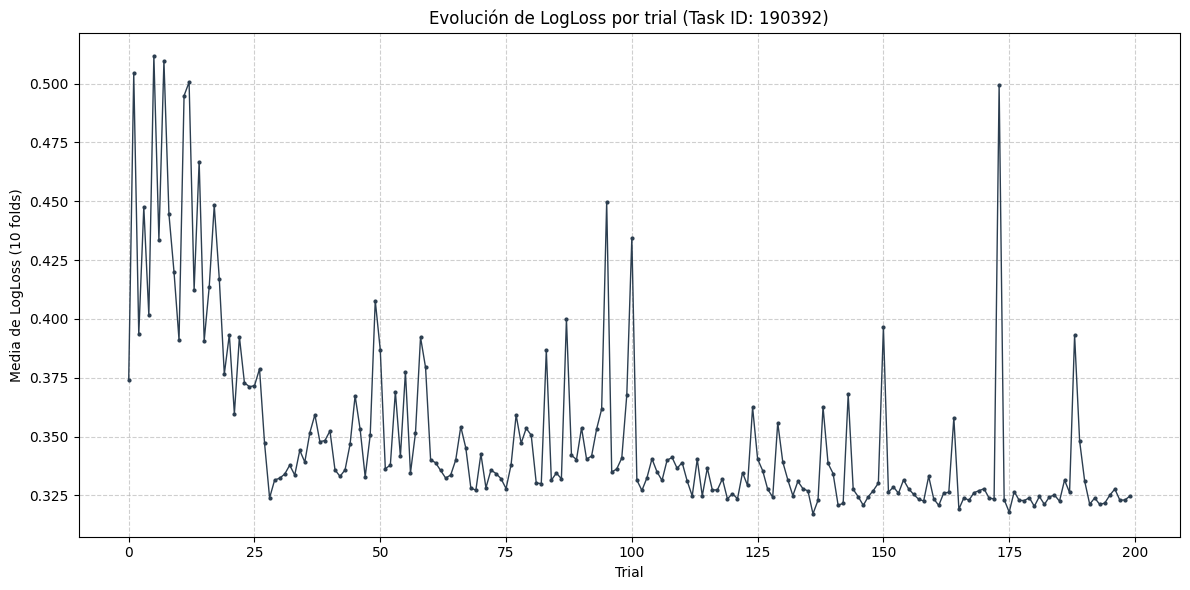

In [8]:
graficar_logloss_por_trial(df, 190392)

## Dibujando las curvas

In [9]:
def graficar_fold(df, task_id, trial_id, fold_id):
    row = df[(df['task_id'] == task_id) & 
             (df['trial_id'] == trial_id) & 
             (df['fold_id'] == fold_id)].iloc[0]
    
    cols_train = [c for c in df.columns if c.startswith('train_')]
    cols_val = [c for c in df.columns if c.startswith('val_')]
    
    y_train = row[cols_train].dropna().values
    y_val = row[cols_val].dropna().values
    
    plt.figure(figsize=(10, 5))
    plt.plot(y_train, label='Train LogLoss', color='blue')
    plt.plot(y_val, label='Val LogLoss', color='orange')
    
    plt.title(f"Train vs Val - Task: {task_id} | Trial: {trial_id} | Fold: {fold_id}")
    plt.xlabel("Iteración")
    plt.ylabel("LogLoss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

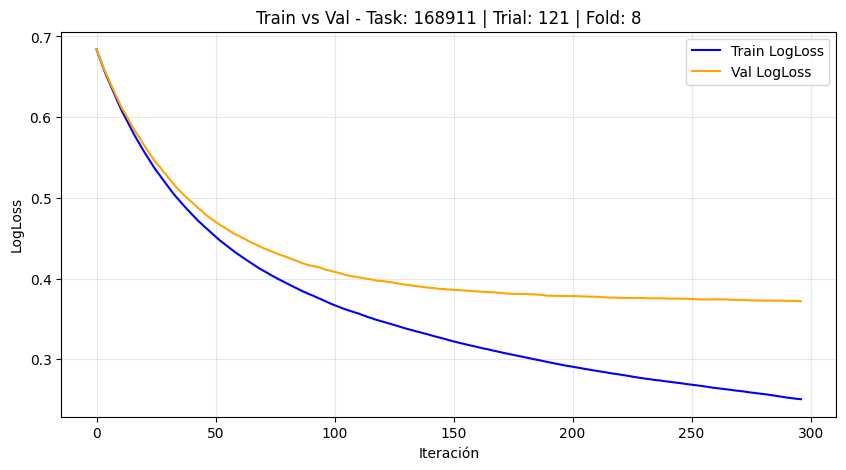

In [10]:
graficar_fold(df, 168911, 121, 8)

In [11]:
def graficar_train_trial(df, task_id, trial_id):
    subset = df[(df['task_id'] == task_id) & (df['trial_id'] == trial_id)]
    cols_train = [c for c in df.columns if c.startswith('train_')]
    
    plt.figure(figsize=(10, 5))
    for idx, row in subset.iterrows():
        y = row[cols_train].dropna().values
        plt.plot(y, alpha=0.6, label=f"Fold {int(row['fold_id'])}")
    
    plt.title(f"Curvas de TRAIN (10 pliegues) - Task: {task_id} | Trial: {trial_id}")
    plt.xlabel("Iteración")
    plt.ylabel("LogLoss")
    plt.legend(title="Folds", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

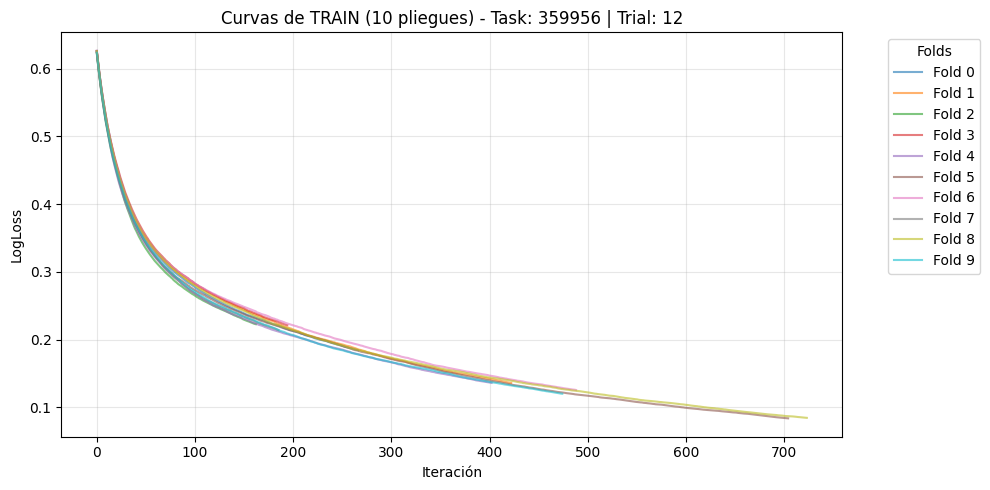

In [12]:
graficar_train_trial(df, 359956, 12)

In [13]:
def graficar_val_trial(df, task_id, trial_id):
    subset = df[(df['task_id'] == task_id) & (df['trial_id'] == trial_id)]
    cols_val = [c for c in df.columns if c.startswith('val_')]
    
    plt.figure(figsize=(10, 5))
    for idx, row in subset.iterrows():
        y = row[cols_val].dropna().values
        plt.plot(y, alpha=0.6, label=f"Fold {int(row['fold_id'])}")
    
    plt.title(f"Curvas de VAL (10 pliegues) - Task: {task_id} | Trial: {trial_id}")
    plt.xlabel("Iteración")
    plt.ylabel("LogLoss")
    plt.legend(title="Folds", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

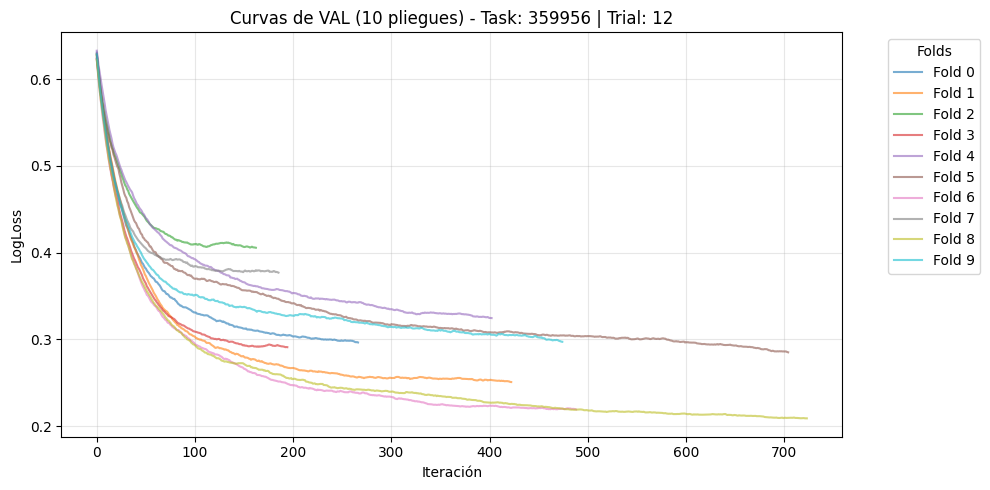

In [14]:
graficar_val_trial(df, 359956, 12)

In [15]:
def graficar_train_val_todos_datasets(df, tasks, trial_ids, fold_id=5):
    """
    df        : DataFrame con los datos
    tasks     : lista de 20 task_id (en orden)
    trial_ids : lista de 20 trial_id, uno por dataset
    fold_id   : pliegue fijo (default 5)
    """
    assert len(tasks) == len(trial_ids), "tasks y trial_ids deben tener el mismo tamaño"

    cols_train = [c for c in df.columns if c.startswith('train_')]
    cols_val   = [c for c in df.columns if c.startswith('val_')]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

    for task_id, trial_id in zip(tasks, trial_ids):
        fila = df[
            (df['task_id'] == task_id) &
            (df['trial_id'] == trial_id) &
            (df['fold_id'] == fold_id)
        ]
        if fila.empty:
            print(f"   Sin datos: task={task_id}, trial={trial_id}, fold={fold_id}")
            continue

        label = f"Task {task_id}"
        y_train = fila.iloc[0][cols_train].dropna().values
        y_val   = fila.iloc[0][cols_val].dropna().values

        line, = ax1.plot(y_train, label=label)
        ax2.plot(y_val, color=line.get_color()) 

    for ax, titulo in zip([ax1, ax2], ["Entrenamiento", "Validación"]):
        ax.set_title(titulo)
        ax.set_xlabel("Iteración")
        ax.grid(True, alpha=0.3)

    ax1.set_ylabel("LogLoss")

    # Leyenda 
    handles, labels = ax1.get_legend_handles_labels()
    fig.legend(handles, labels, loc='center right',
               bbox_to_anchor=(1.01, 0.5), fontsize=9)

    plt.suptitle(f"TPESampler", fontsize=14, y=0.98)
    plt.tight_layout()
    plt.subplots_adjust(right=0.89)
    #plt.savefig("CurvasTPE.png", dpi=200, bbox_inches='tight')
    plt.show()

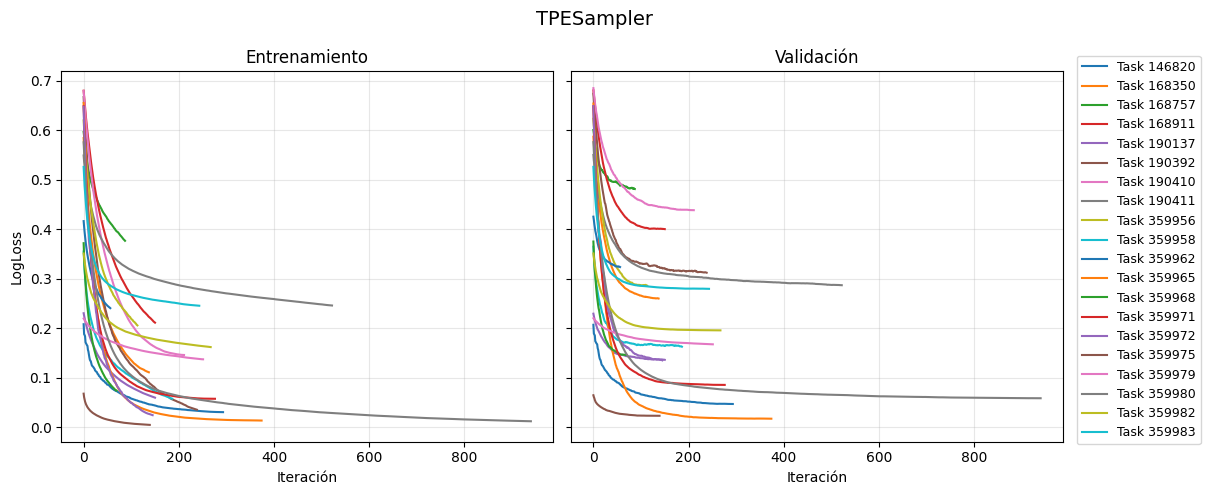

In [16]:
graficar_train_val_todos_datasets(df, tasks, [1,142,132,145,123,137,183,122,73,56,38,25,21,123,183,92,21,67,84,21], fold_id=3)